# 01 Data Audit

Inspect raw annotation files, class balance, duplicates, and sentiment-bearing symbols before training.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.data_utils import build_paths, discover_raw_files, merge_annotation_files, build_label_audit

paths = build_paths()
raw_files = discover_raw_files(paths.raw_dir)
raw_files

[WindowsPath('C:/Users/vdchi/OneDrive/Documents/DATA SCIENCE/Sem5/Group Project/Prototyping 2/data/raw/Copy of Facebook_Comment_Annotation - Perpetual.csv'),
 WindowsPath('C:/Users/vdchi/OneDrive/Documents/DATA SCIENCE/Sem5/Group Project/Prototyping 2/data/raw/facebook-comment-annotation2 - Exposition.csv'),
 WindowsPath('C:/Users/vdchi/OneDrive/Documents/DATA SCIENCE/Sem5/Group Project/Prototyping 2/data/raw/facebook-comment-annotation2 - Fitina.csv'),
 WindowsPath('C:/Users/vdchi/OneDrive/Documents/DATA SCIENCE/Sem5/Group Project/Prototyping 2/data/raw/facebook-comment-annotation2 - Luthando.csv'),
 WindowsPath('C:/Users/vdchi/OneDrive/Documents/DATA SCIENCE/Sem5/Group Project/Prototyping 2/data/raw/facebook-comment-annotation2 - Perpetual.csv'),
 WindowsPath('C:/Users/vdchi/OneDrive/Documents/DATA SCIENCE/Sem5/Group Project/Prototyping 2/data/raw/facebook-comment-annotation2 - Rahema.csv'),
 WindowsPath('C:/Users/vdchi/OneDrive/Documents/DATA SCIENCE/Sem5/Group Project/Prototyping 2

In [2]:
EXPECTED_COLUMNS = {"id", "text", "sentiment_label", "include"}
def load_annotation_file(file_path: Path) -> pd.DataFrame:
    df = pd.read_csv(file_path)
    df = df.rename(
        columns={
            "Unnamed: 0": "id",
            "topic-label": "topic_label",
            "sentiment-label": "sentiment_label",
            "Include": "include",
        }
    )
    missing = EXPECTED_COLUMNS - set(df.columns)
    if missing:
        missing_cols = ", ".join(sorted(missing))
        raise ValueError(f"{file_path.name} is missing required columns: {missing_cols}")
    df = df.copy()
    df["source_file"] = file_path.name
    return df

In [4]:
dfs = [load_annotation_file(f) for f in raw_files]

In [5]:
columns = [df.columns for df in dfs]
columns

[Index(['id', 'text', 'topic_label', 'sentiment_label', 'confidence', 'include',
        'notes', 'source_file'],
       dtype='object'),
 Index(['id', 'text', 'topic_label', 'sentiment_label', 'confidence', 'include',
        'notes', 'source_file'],
       dtype='object'),
 Index(['id', 'text', 'topic_label', 'sentiment_label', 'confidence', 'include',
        'notes', 'source_file'],
       dtype='object'),
 Index(['id', 'text', 'topic_label', 'sentiment_label', 'confidence', 'include',
        'notes', 'source_file'],
       dtype='object'),
 Index(['id', 'text', 'topic_label', 'sentiment_label', 'confidence', 'include',
        'notes', 'source_file'],
       dtype='object'),
 Index(['id', 'text', 'topic_label', 'sentiment_label', 'confidence', 'include',
        'notes', 'source_file'],
       dtype='object'),
 Index(['id', 'text', 'topic_label', 'sentiment_label', 'confidence', 'include',
        'notes', 'source_file'],
       dtype='object'),
 Index(['id', 'text', 'topic_label

In [6]:
indices = [df.index for df in dfs]
indices

[RangeIndex(start=0, stop=80, step=1),
 RangeIndex(start=0, stop=80, step=1),
 RangeIndex(start=0, stop=80, step=1),
 RangeIndex(start=0, stop=80, step=1),
 RangeIndex(start=0, stop=80, step=1),
 RangeIndex(start=0, stop=80, step=1),
 RangeIndex(start=0, stop=80, step=1),
 RangeIndex(start=0, stop=80, step=1),
 RangeIndex(start=0, stop=80, step=1),
 RangeIndex(start=0, stop=80, step=1),
 RangeIndex(start=0, stop=80, step=1),
 RangeIndex(start=0, stop=80, step=1),
 RangeIndex(start=0, stop=52, step=1),
 RangeIndex(start=0, stop=80, step=1),
 RangeIndex(start=0, stop=52, step=1),
 RangeIndex(start=0, stop=51, step=1),
 RangeIndex(start=0, stop=34, step=1),
 RangeIndex(start=0, stop=34, step=1),
 RangeIndex(start=0, stop=35, step=1),
 RangeIndex(start=0, stop=35, step=1),
 RangeIndex(start=0, stop=47, step=1),
 RangeIndex(start=0, stop=34, step=1),
 RangeIndex(start=0, stop=161, step=1),
 RangeIndex(start=0, stop=164, step=1),
 RangeIndex(start=0, stop=163, step=1),
 RangeIndex(start=0, s

In [7]:
dfs = [load_annotation_file(f) for f in raw_files]
pd.concat(dfs, ignore_index=True)

,id,text,topic_label,sentiment_label,confidence,include,notes,source_file
0,330.0,Good movie,Economy,Positive,Low,No,no topic,Copy of Facebook_Comment_Annotation - Perpetua...
1,331.0,Salute,Economy,Positive,Low,No,too short,Copy of Facebook_Comment_Annotation - Perpetua...
2,332.0,Zamphamvu kwambiri,Economy,positive,Medium,Yes,praise,Copy of Facebook_Comment_Annotation - Perpetua...
3,333.0,The machine,Economy,Neutral,Low,No,unclear,Copy of Facebook_Comment_Annotation - Perpetua...
4,334.0,"Learning by doing approach, that's wonderful 🔥 🔥.",Economy,positive,High,Yes,teaching method,Copy of Facebook_Comment_Annotation - Perpetua...
...,...,...,...,...,...,...,...,...
3544,NaN,NaN,economy,NaN,NaN,NaN,NaN,sentiment2 spreadsheet - viwongo.csv
3545,NaN,NaN,economy,NaN,NaN,NaN,NaN,sentiment2 spreadsheet - viwongo.csv
3546,NaN,NaN,economy,NaN,NaN,NaN,NaN,sentiment2 spreadsheet - viwongo.csv
3547,NaN,NaN,economy,NaN,NaN,NaN,NaN,sentiment2 spreadsheet - viwongo.csv


In [8]:
merged = merge_annotation_files(raw_files)
audit = build_label_audit(merged)
merged.tail()

,id,text,topic_label,sentiment_label,confidence,include,notes,source_file
3544,NaN,NaN,economy,NaN,NaN,NaN,NaN,sentiment2 spreadsheet - viwongo.csv
3545,NaN,NaN,economy,NaN,NaN,NaN,NaN,sentiment2 spreadsheet - viwongo.csv
3546,NaN,NaN,economy,NaN,NaN,NaN,NaN,sentiment2 spreadsheet - viwongo.csv
3547,NaN,NaN,economy,NaN,NaN,NaN,NaN,sentiment2 spreadsheet - viwongo.csv
3548,NaN,NaN,economy,NaN,NaN,NaN,NaN,sentiment2 spreadsheet - viwongo.csv


In [11]:
merged[merged["source_file"] == "sentiment2 spreadsheet - viwongo.csv"]

,id,text,topic_label,sentiment_label,confidence,include,notes,source_file
3346,332.0,Great man ever,economy,positive,high,yes,NaN,sentiment2 spreadsheet - viwongo.csv
3347,333.0,Bravo Mr bushiri,economy,positive,high,yes,NaN,sentiment2 spreadsheet - viwongo.csv
3348,334.0,Good news,economy,positive,high,yes,NaN,sentiment2 spreadsheet - viwongo.csv
3349,335.0,Kukhala si Uku!!!!,economy,negative,high,yes,NaN,sentiment2 spreadsheet - viwongo.csv
3350,336.0,Dolo ka 10,economy,positive,high,yes,NaN,sentiment2 spreadsheet - viwongo.csv
...,...,...,...,...,...,...,...,...
3544,NaN,NaN,economy,NaN,NaN,NaN,NaN,sentiment2 spreadsheet - viwongo.csv
3545,NaN,NaN,economy,NaN,NaN,NaN,NaN,sentiment2 spreadsheet - viwongo.csv
3546,NaN,NaN,economy,NaN,NaN,NaN,NaN,sentiment2 spreadsheet - viwongo.csv
3547,NaN,NaN,economy,NaN,NaN,NaN,NaN,sentiment2 spreadsheet - viwongo.csv


In [9]:
audit.columns

Index(['id', 'text', 'topic_label', 'sentiment_label', 'confidence', 'include',
       'notes', 'source_file', 'sentiment_label_normalized',
       'include_normalized', 'text_missing', 'text_length_chars',
       'token_count_whitespace', 'is_short_comment', 'is_duplicate_text',
       'exclude_reason'],
      dtype='object')

In [13]:
merged[merged["text"] == "Mbambande 🔥"]

,id,text,topic_label,sentiment_label,confidence,include,notes,source_file
93,98.0,Mbambande 🔥,Economy,Positive,High,Yes,NaN,Facebook_Comment_Annotation - Alfred.csv
153,161.0,Mbambande 🔥,Economy,Positive,High,Yes,NaN,Facebook_Comment_Annotation - Alfred.csv
416,184.0,Mbambande 🔥,Economy,Positive,High,Yes,NaN,Facebook_Comment_Annotation - Thando.csv
426,195.0,Mbambande 🔥,Economy,Positive,High,Yes,NaN,Facebook_Comment_Annotation - Thando.csv
2651,263.0,Mbambande 🔥,economy,positive,low,yes,NaN,sentiment2 spreadsheet - fitina.csv


In [14]:
audit[['source_file', 'sentiment_label', 'sentiment_label_normalized', 'include', 'exclude_reason']].head(10)

,source_file,sentiment_label,sentiment_label_normalized,include,exclude_reason
0,Copy of Facebook_Comment_Annotation - Perpetua...,Positive,positive,No,include_not_yes
1,Copy of Facebook_Comment_Annotation - Perpetua...,Positive,positive,No,include_not_yes
2,Copy of Facebook_Comment_Annotation - Perpetua...,positive,positive,Yes,
3,Copy of Facebook_Comment_Annotation - Perpetua...,Neutral,neutral,No,include_not_yes
4,Copy of Facebook_Comment_Annotation - Perpetua...,positive,positive,Yes,
5,Copy of Facebook_Comment_Annotation - Perpetua...,Neutral,neutral,Yes,
6,Copy of Facebook_Comment_Annotation - Perpetua...,positive,positive,Yes,
7,Copy of Facebook_Comment_Annotation - Perpetua...,Neutral,neutral,Yes,
8,Copy of Facebook_Comment_Annotation - Perpetua...,positive,positive,No,include_not_yes
9,Copy of Facebook_Comment_Annotation - Perpetua...,negative,negative,Yes,


In [15]:
audit['sentiment_label_normalized'].value_counts(dropna=False)

,count
sentiment_label_normalized,
positive,1334
negative,1325
neutral,827
None,63


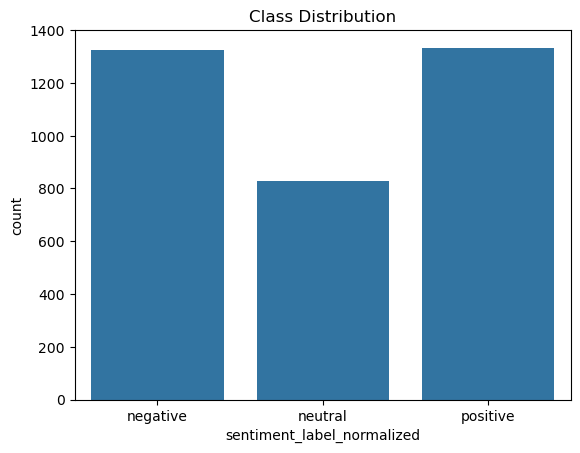

In [10]:
sns.countplot(data=audit, x='sentiment_label_normalized', order=['negative', 'neutral', 'positive'])
plt.title('Class Distribution')
plt.show()

In [16]:
audit['text_length_chars'].describe()

,text_length_chars
count,3549.000000
mean,56.551986
std,83.790691
min,0.000000
25%,19.000000
50%,37.000000
75%,66.000000
max,1980.000000


In [19]:
emoji_counts = merged['text'].fillna('').str.count(r'[\U00010000-\U0010ffff]')
emoji_counts.describe()

,text
count,3549.000000
mean,0.699352
std,1.956849
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,60.000000


In [20]:
audit[audit['exclude_reason'] != ''][['text', 'exclude_reason', 'source_file']].head(20)

,text,exclude_reason,source_file
0,Good movie,include_not_yes,Copy of Facebook_Comment_Annotation - Perpetua...
1,Salute,include_not_yes,Copy of Facebook_Comment_Annotation - Perpetua...
3,The machine,include_not_yes,Copy of Facebook_Comment_Annotation - Perpetua...
8,Keep it up mr🤗Home sweet home❤💫,include_not_yes,Copy of Facebook_Comment_Annotation - Perpetua...
13,Enafe ndiongepelekeza padzikoli,include_not_yes,Copy of Facebook_Comment_Annotation - Perpetua...
16,Kudya kulipo ......:,include_not_yes,Copy of Facebook_Comment_Annotation - Perpetua...
26,Mpulumutsi,include_not_yes,Copy of Facebook_Comment_Annotation - Perpetua...
29,Go ahead.,include_not_yes,Copy of Facebook_Comment_Annotation - Perpetua...
30,Dolo uyuyu,include_not_yes,Copy of Facebook_Comment_Annotation - Perpetua...
34,Nzeru zobambo transport,include_not_yes,Copy of Facebook_Comment_Annotation - Perpetua...
